In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd

## Исходные данные и настройки

In [3]:
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IrGUPS_dolg_list_11_12_2024.csv', encoding='cp1251', sep=';') # Последние данные

Если предполагается анализ динамики по разным датам, отметить пункт "Будем сравнивать" и внести имя файла со "старыми" данными:

In [4]:
compare = True

In [5]:
if compare:
    data_old = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/IrGUPS_dolg_list_16_09_2024.csv', encoding='cp1251', sep=';')

**Необходимо выбрать дату (если будем сравнивать - то период)** <br>
Даты необходимы для подписи пояснений, графиков и т.д.

In [6]:
import datetime
dates = (datetime.date(2024, 9, 16), datetime.date(2024, 12, 11))

**Первоначальный анализ загруженных данных**

In [7]:
data

,N п/п,Группа,Студент,Кафедра,Предмет,Тип предмета,Преподаватель,Курс,Семестр,Форма обучения,Основа обучения
0,1,"ИС.1-23-2(И,З)",Комаров Дмитрий Александрович,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),внебюджет
1,2,"ИС.1-23-2(И,З)",Сосюк Николай Иванович,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),внебюджет
2,3,"ИС.1-23-2(И,З)",Федосеева Оксана Юрьевна,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),бюджет
3,4,"ИС.1-23-2(И,З)",Сафонова Татьяна Викторовна,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),бюджет
4,5,"ИС.1-23-2(И,З)",Хижняк Данил Алексеевич,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),внебюджет
...,...,...,...,...,...,...,...,...,...,...,...
22714,22715,"СЖД.3-23-1(И,О)",Романов Игнатий Святославович,NaN,История России,диф.зачет,Дятлова Нина Ивановна,1,2,специалитет (очное),внебюджет
22715,22716,"СЖД.2-23-1(И,О)",Пэрэнлий Пурэв-Эрдэнэ,NaN,История России,диф.зачет,Дятлова Нина Ивановна,1,2,специалитет (очное),бюджет
22716,22717,"СЖД.2-23-1(И,О)",Романов Даниил Сергеевич,NaN,История России,диф.зачет,Дятлова Нина Ивановна,1,2,специалитет (очное),целевой
22717,22718,"СЖД.2-23-1(И,О)",Смирнов Егор Алексеевич,NaN,История России,диф.зачет,Дятлова Нина Ивановна,1,2,специалитет (очное),целевой


In [8]:
data_old.head()

,N п/п,Группа,Студент,Кафедра,Предмет,Тип предмета,Преподаватель,Курс,Семестр,Форма обучения,Основа обучения
0,1,"ИС.1-23-2(И,З)",Комаров Дмитрий Александрович,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),внебюджет
1,2,"ИС.1-23-2(И,З)",Сосюк Николай Иванович,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),внебюджет
2,3,"ИС.1-23-2(И,З)",Федосеева Оксана Юрьевна,Иностранные языки,Иностранный язык,зачет,Казарина Ирина Николаевна,1,1,бакалавриат (заочное),бюджет
3,4,"ИС.1-23-2(И,З)",Комаров Дмитрий Александрович,NaN,Основы российской государственности,зачет,Бобылева Ольга Михайловна,1,1,бакалавриат (заочное),внебюджет
4,5,"ИС.1-23-2(И,З)",Сосюк Николай Иванович,NaN,Основы российской государственности,зачет,Бобылева Ольга Михайловна,1,1,бакалавриат (заочное),внебюджет


Общая информация по таблице:

In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22719 entries, 0 to 22718
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   N п/п            22719 non-null  int64 
 1   Группа           22719 non-null  object
 2   Студент          22719 non-null  object
 3   Кафедра          17203 non-null  object
 4   Предмет          22719 non-null  object
 5   Тип предмета     22719 non-null  object
 6   Преподаватель    22088 non-null  object
 7   Курс             22719 non-null  int64 
 8   Семестр          22719 non-null  int64 
 9   Форма обучения   22719 non-null  object
 10  Основа обучения  22719 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [10]:
data_old.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26569 entries, 0 to 26568
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   N п/п            26569 non-null  int64 
 1   Группа           26569 non-null  object
 2   Студент          26569 non-null  object
 3   Кафедра          20566 non-null  object
 4   Предмет          26569 non-null  object
 5   Тип предмета     26569 non-null  object
 6   Преподаватель    25782 non-null  object
 7   Курс             26569 non-null  int64 
 8   Семестр          26569 non-null  int64 
 9   Форма обучения   26569 non-null  object
 10  Основа обучения  26569 non-null  object
dtypes: int64(3), object(8)
memory usage: 2.2+ MB


Есть пропуски в столбцах "Преподаватель" и "Кафедра"

In [11]:
# Заполним пропуски заглушками
data['Кафедра'] = data['Кафедра'].fillna('Кафедра не указана')
data['Преподаватель'] = data['Преподаватель'].fillna('Неизвестный')

if compare:
    data_old['Кафедра'] = data_old['Кафедра'].fillna('Кафедра не указана')
    data_old['Преподаватель'] = data_old['Преподаватель'].fillna('Неизвестный')

In [12]:
data[~data['Группа'].str.contains('-')]

,N п/п,Группа,Студент,Кафедра,Предмет,Тип предмета,Преподаватель,Курс,Семестр,Форма обучения,Основа обучения


Добавим столбец с текущим семестром для нахождения старых долгов.<br>
*Пока заглушка для осени 2024 года, нужно доработать для произвольного времени.*

In [14]:
def get_year(group):
    return int(group.split('-')[1])

data['Текущий_семестр'] = data['Группа'].apply(get_year)
data['Текущий_семестр'] = (24 - data['Текущий_семестр']) * 2  + 1 # Заглушка!!! Осень 24

if compare:
    data_old['Текущий_семестр'] = data_old['Группа'].apply(get_year)
    data_old['Текущий_семестр'] = (24 - data_old['Текущий_семестр']) * 2  # Заглушка!!! Осень 24

In [15]:
# проверим на случайном наборе данных
data[['Группа', 'Студент', 'Текущий_семестр']].sample(5)

,Группа,Студент,Текущий_семестр
5979,"ЭЖД.1-23-2(И,О)",Снегирев Лев Максимович,3
11842,"СОД.2-21-1(И,З)",Чудайкин Евгений Александрович,7
22220,"СЖД.3-21-1(И,О)",Ткаченко Ярослав Сергеевич,7
1666,"БИ.4-22-1(И,О)",Аганаев Эдуард Иванович,5
20750,"СЖД.1-21-1(И,З)",Черкашина Анастасия Павловна,7


**Необходимо выбрать форму обучения для дальнейшего анализа**

In [16]:
forma = "Только очная"

In [17]:
if forma == 'Только очная':
    data = data[data['Группа'].str.endswith('(И,О)')]
    if compare:
        data_old = data_old[data_old['Группа'].str.endswith('(И,О)')]
elif forma == 'Только заочная':
    data = data[data['Группа'].str.endswith('(И,З)')]
    if compare:
        data_old = data_old[data_old['Группа'].str.endswith('(И,З)')]


In [18]:
print('Форма обучения:', forma)

print('Текущие данные на', dates[1])
print('\tКоличество долгов:', data.shape[0])
print('\tКоличество студентов с долгами (включая практику):', data['Студент'].unique().size)

if compare:
    print('\nПервоначальные данные на', dates[0])
    print('\tКоличество долгов:', data_old.shape[0])
    print('\tКоличество студентов с долгами (включая практику):', data_old['Студент'].unique().size)

Форма обучения: Только очная
Текущие данные на 2024-12-11
	Количество долгов: 16195
	Количество студентов с долгами (включая практику): 1627

Первоначальные данные на 2024-09-16
	Количество долгов: 20348
	Количество студентов с долгами (включая практику): 2236


**Исключим практику из рассмотрения (ее необходимо рассмотреть отдельно)**

In [19]:
praktika = False

In [20]:
if not praktika:
    data = data[~(data['Предмет'].str.startswith('Учебная') | data['Предмет'].str.startswith('Производственная'))]

    if compare:
        data_old = data_old[~(data_old['Предмет'].str.startswith('Учебная') | data_old['Предмет'].
                                                                                str.startswith('Производственная'))]

In [21]:
if praktika:
    print('С учетом практики')
else:
    print('Без учета практики')

print('Текущие данные на', dates[1])
print('\tКоличество долгов:', data.shape[0])
print('\tКоличество студентов с долгами:', data['Студент'].unique().size)

if compare:
    print('\nПервоначальные данные на', dates[0])
    print('\tКоличество долгов:', data_old.shape[0])
    print('\tКоличество студентов с долгами:', data_old['Студент'].unique().size)

Без учета практики
Текущие данные на 2024-12-11
	Количество долгов: 15278
	Количество студентов с долгами: 1566

Первоначальные данные на 2024-09-16
	Количество долгов: 18141
	Количество студентов с долгами: 1666


## Общее число долгов

**Отсортируем студентов по общему количеству долгов:**

In [22]:
print('Текущие данные на', dates[1])
group_by_st = data[['Студент', 'Группа', 'Предмет']].groupby(['Студент', 'Группа']).\
              count().sort_values('Предмет', ascending=False).reset_index()
group_by_st = group_by_st.rename(columns={'Предмет': 'Долги'})

group_by_st

Текущие данные на 2024-12-11


,Студент,Группа,Долги
0,Чжэн Эньцзэ,"Э.9-21-1(И,О)",51
1,Коростелёва Дарья Александровна,"СОД.1-20-2(И,О)",47
2,Муратбек Анар,"СОД.3-20-1(И,О)",44
3,Гаврилова София Владимировна,"ПСЖ.6-20-1(И,О)",43
4,Бутин Владислав Альбертович,"ПСЖ.3-21-1(И,О)",43
...,...,...,...
1562,Сушко Анастасия Денисовна,"Э.8-22-1(И,О)",1
1563,Колодин Сергей Дмитриевич,"ИС.1-23-2(И,О)",1
1564,Цыденова Ангелина Алдаровна,"М.3-21-1(И,О)",1
1565,Бубнов Сергей Евгеньевич,"СОД.1-22-1(И,О)",1


**Построим гистограммы по количеству задолженностей**

In [23]:
# !!! только для сравнения !!!
if compare:
    group_old_by_st = data_old[['Студент', 'Группа', 'Предмет']].groupby(['Студент', 'Группа']).\
              count().sort_values('Предмет', ascending=False).reset_index()
    group_old_by_st = group_old_by_st.rename(columns={'Предмет': 'Долги'})

    group_by_st_comp = group_old_by_st.merge(group_by_st, on=['Студент', 'Группа'], how='outer', suffixes=('_было', '_стало'))
    display(group_by_st_comp)

,Студент,Группа,Долги_было,Долги_стало
0,Абалаков Дмитрий Александрович,"СОД.1-23-2(И,О)",2.0,2.0
1,Абалаков Кирилл Алексеевич,"ЭЖД.1-22-2(И,О)",7.0,5.0
2,Аббасов Эмиль Аязович,"СЖД.2-21-1(И,О)",8.0,6.0
3,Абдуллоев Мухаммадаминджон Маъруфджонович,"БАС.5-23-1(И,О)",2.0,2.0
4,Абдуллоев Некруз Носирджонович,"ПСЖ.3-23-1(И,О)",1.0,NaN
...,...,...,...,...
1725,Ястребова Наталья Алексеевна,"Э.8-23-1(И,О)",3.0,NaN
1726,Яцемирский Антон Андреевич,"Т.1-21-2(И,О)",5.0,5.0
1727,Яшин Константин Владимирович,"СОД.3-21-1(И,О)",9.0,3.0
1728,Яшин Семён Александрович,"ЭЖД.1-23-2(И,О)",7.0,4.0


In [24]:
if compare:
    print('Полностью закрыли долги: ', group_by_st_comp[group_by_st_comp['Долги_стало'].isna()]['Студент'].count(), 'чел.')
    display(group_by_st_comp[group_by_st_comp['Долги_стало'].isna()])
    print('\n(отчислены, ушли в академ или Молодцы!!!)')

Полностью закрыли долги:  163 чел.


,Студент,Группа,Долги_было,Долги_стало
4,Абдуллоев Некруз Носирджонович,"ПСЖ.3-23-1(И,О)",1.0,NaN
20,Акопкин Данил Андреевич,"ПСЖ.3-23-1(И,О)",18.0,NaN
38,Алиев Фарид Эльсун оглы,"Т.1-23-3(И,О)",1.0,NaN
39,Алижонов Бахромжон Тухтасин угли,"СОД.1-22-2(И,О)",16.0,NaN
76,Астапенко Никита Николаевич,"КТ.1-22-1(И,О)",36.0,NaN
...,...,...,...,...
1643,Шахоцкая Анна Романовна,"СОД.2-23-1(И,О)",1.0,NaN
1665,Шеремет Валерия Дмитриевна,"СОД.2-22-1(И,О)",12.0,NaN
1691,Шпис Алексей Витальевич,"КТ.1-21-1(И,О)",36.0,NaN
1705,Энхтувшин Энхнаран,"ПСЖ.6-20-1(И,О)",52.0,NaN



(отчислены, ушли в академ или Молодцы!!!)


In [25]:
if compare:
    print('Появились долги: ', group_by_st_comp[group_by_st_comp['Долги_было'].isna()]['Студент'].count(), 'чел. ?!?')
    display(group_by_st_comp[group_by_st_comp['Долги_было'].isna()])
    print('\n(вышли из академа, восстановились, либо что-то пошло не так...)')

Появились долги:  61 чел. ?!?


,Студент,Группа,Долги_было,Долги_стало
59,Аникьев Виталий Александрович,"ИС.1-23-2(И,О)",NaN,7.0
94,Бабенцев Тимофей Максимович,"КТ.1-21-1(И,О)",NaN,32.0
113,Балданов Элбэг Саянович,"Т-20-2(И,О)",NaN,6.0
139,Батсайхан Аззаяа,"СОД.2-20-1(И,О)",NaN,13.0
196,Большедворский-Федин Иван Алексеевич,"ТТП.1-23-1(И,О)",NaN,16.0
...,...,...,...,...
1678,Шиховцев Роман Романович,"СОД.1-20-1(И,О)",NaN,7.0
1689,Шорников Антон Сергеевич,"БИ.4-21-1(И,О)",NaN,8.0
1693,Шубина Дарья Александровна,"ТБ.2-21-1(И,О)",NaN,3.0
1699,Щербаков Арсений Иванович,"БИ.4-21-1(И,О)",NaN,8.0



(вышли из академа, восстановились, либо что-то пошло не так...)


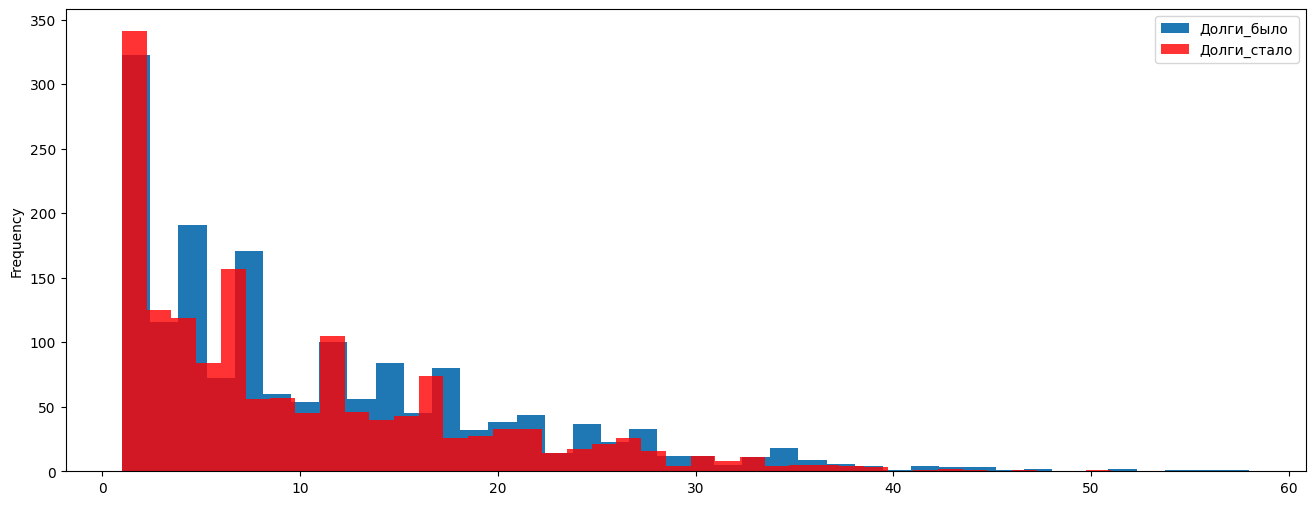

In [26]:
if compare:
    group_by_st_comp['Долги_было'].plot(kind='hist', bins=40, figsize=(16,6), legend=True, xlabel='Количество долгов');
    group_by_st_comp['Долги_стало'].plot(kind='hist', bins=40, figsize=(16,6), color='red', alpha=0.8, legend=True);

другой график:

In [27]:
curr_freq = group_by_st.groupby('Долги')['Студент'].count()
curr_table = pd.DataFrame(curr_freq).reset_index().rename(columns={'Долги' : 'Количество_долгов', 'Студент' : 'Должников_сейчас'})

if compare:
    prev_freq = group_by_st_comp.groupby('Долги_было')['Студент'].count()
    prev_table = pd.DataFrame(prev_freq).reset_index().rename(columns={'Долги_было' : 'Количество_долгов', 'Студент' : 'Должников_было'})
    comp_table = prev_table.merge(curr_table, on='Количество_долгов', how='outer').fillna(0)

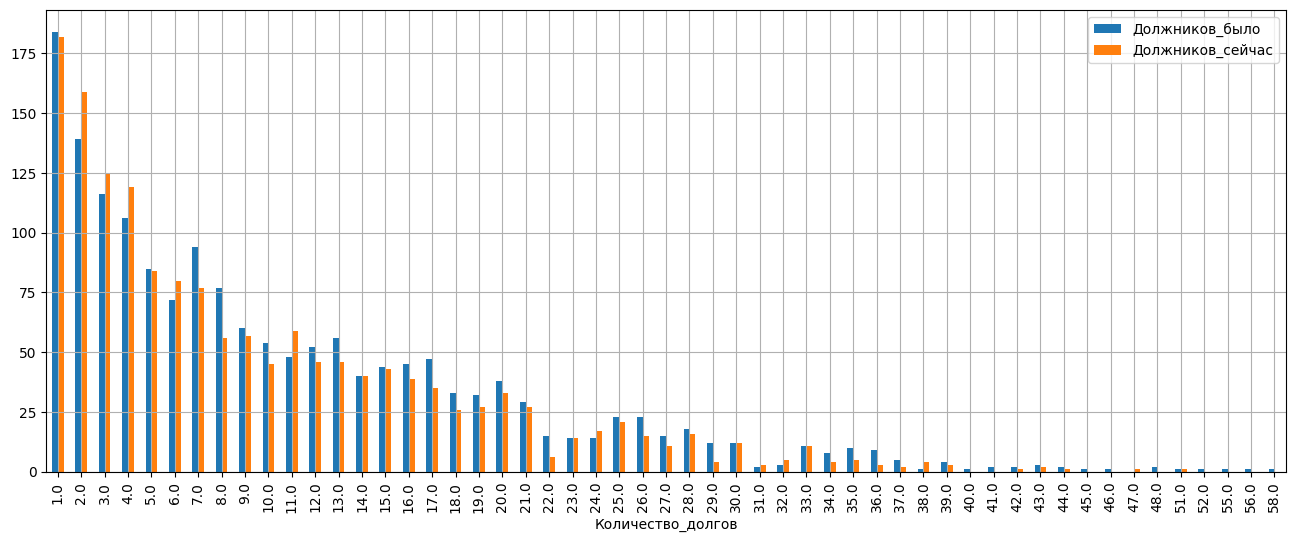

In [28]:
if compare:
    comp_table.plot(kind='bar', x='Количество_долгов', y=['Должников_было', 'Должников_сейчас'], figsize=(16,6), grid=True)
else:
    curr_table.plot(kind='bar', x='Количество_долгов', y='Должников_сейчас', figsize=(16,6), grid=True)

Количество долгов по курсам обучения (курс получения долга)

In [29]:
curs_freq = data.groupby('Курс')['Студент'].count()

<Axes: xlabel='Курс'>

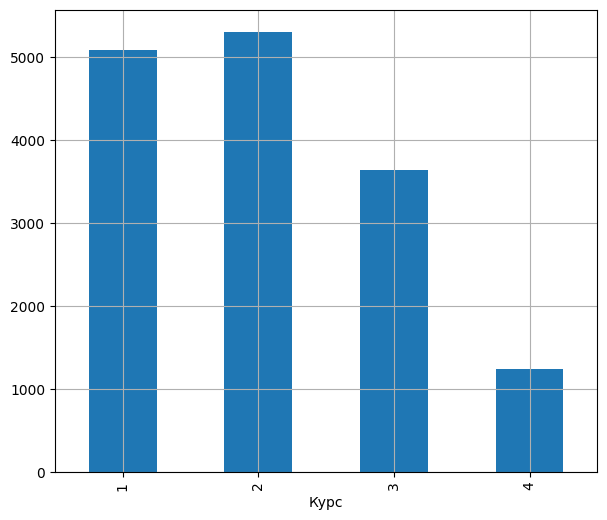

In [30]:
curs_freq.plot(kind='bar', x='Курс', y='Студент', figsize=(7,6), grid=True)

Количество должников по курсам

In [31]:
st_curs_freq = data.groupby('Текущий_семестр')['Студент'].count()

<Axes: xlabel='Текущий_семестр'>

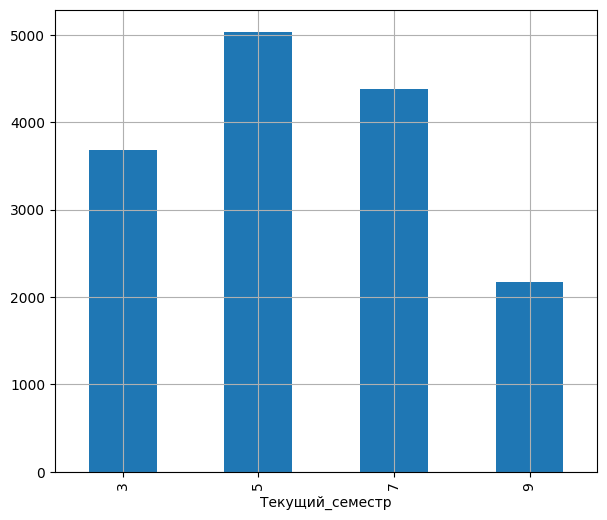

In [32]:
st_curs_freq.plot(kind='bar', x='Текущий_семестр', y='Студент', figsize=(7,6), grid=True)

**Сформируем списки по количеству долгов**

In [33]:
dolgi_max = 20

In [34]:
filtr_dolgi = group_by_st[group_by_st['Долги'] > dolgi_max]
n_count = group_by_st['Студент'].count()
n_sum = group_by_st['Долги'].sum()


print('Форма обучения:', forma)
print('Кол-во должников:', n_count)
print('Количество долгов:', n_sum)
print('----------------')
print('Число студентов с количеством долгов >',dolgi_max, '=', filtr_dolgi['Студент'].count(), 'чел.')
print('Число их задолженностей:', filtr_dolgi['Долги'].sum(), 'шт.')
print('----------------')
print('Число студентов с количеством долгов <=',dolgi_max, '=', n_count - filtr_dolgi['Студент'].count(), 'чел.')
print('Число их задолженностей:', n_sum - filtr_dolgi['Долги'].sum(), 'шт.')

Форма обучения: Только очная
Кол-во должников: 1567
Количество долгов: 15278
----------------
Число студентов с количеством долгов > 20 = 189 чел.
Число их задолженностей: 5213 шт.
----------------
Число студентов с количеством долгов <= 20 = 1378 чел.
Число их задолженностей: 10065 шт.


Список этих "достойных" людей:

In [35]:
filtr_dolgi

,Студент,Группа,Долги
0,Чжэн Эньцзэ,"Э.9-21-1(И,О)",51
1,Коростелёва Дарья Александровна,"СОД.1-20-2(И,О)",47
2,Муратбек Анар,"СОД.3-20-1(И,О)",44
3,Гаврилова София Владимировна,"ПСЖ.6-20-1(И,О)",43
4,Бутин Владислав Альбертович,"ПСЖ.3-21-1(И,О)",43
...,...,...,...
184,Сухова Светлана Васильевна,"СЖД.2-20-1(И,О)",21
185,Иванов Кирилл Андреевич,"СОД.3-22-1(И,О)",21
186,Ларионова Ангелина Ивановна,"ЭЖД.1-22-1(И,О)",21
187,Солдаткин Степан Александрович,"ПСЖ.6-23-1(И,О)",21


**Кого можно вытащить в ближайшее время? (из должников)**<br>
количество долгов <= 3-х

In [36]:
not_bad_student = group_by_st[group_by_st['Долги'] <= 3]
not_bad_student

,Студент,Группа,Долги
1101,Хребтова Дарья Юрьевна,"СОД.3-20-1(И,О)",3
1102,Жулинец Даниил Сергеевич,"ПСЖ.3-20-1(И,О)",3
1103,Зайцев Даниил Романович,"ИС.1-22-1(И,О)",3
1104,Хальхаев Роман Владимирович,"Т.1-23-1(И,О)",3
1105,Вологдин Кирилл Романович,"ПИ.1-22-1(И,О)",3
...,...,...,...
1562,Сушко Анастасия Денисовна,"Э.8-22-1(И,О)",1
1563,Колодин Сергей Дмитриевич,"ИС.1-23-2(И,О)",1
1564,Цыденова Ангелина Алдаровна,"М.3-21-1(И,О)",1
1565,Бубнов Сергей Евгеньевич,"СОД.1-22-1(И,О)",1


Список долгов:

In [37]:
not_bad_list = not_bad_student.merge(data, on=['Студент', 'Группа'], how='inner')\
    [['Студент', 'Группа', 'Предмет', 'Тип предмета', 'Преподаватель']]
not_bad_list

,Студент,Группа,Предмет,Тип предмета,Преподаватель
0,Хребтова Дарья Юрьевна,"СОД.3-20-1(И,О)",Многоканальная связь на железнодорожном трансп...,зачет,Козиенко Леонид Владимирович
1,Хребтова Дарья Юрьевна,"СОД.3-20-1(И,О)",Передача дискретных сообщений на железнодорожн...,экзамен,Козиенко Леонид Владимирович
2,Хребтова Дарья Юрьевна,"СОД.3-20-1(И,О)",Передача дискретных сообщений на железнодорожн...,курсовая работа,Козиенко Леонид Владимирович
3,Жулинец Даниил Сергеевич,"ПСЖ.3-20-1(И,О)",Механическая часть электроподвижного состава,экзамен,Милованова Евгения Алексеевна
4,Жулинец Даниил Сергеевич,"ПСЖ.3-20-1(И,О)",Тяговые электрические машины,курсовая работа,Линьков Алексей Олегович
...,...,...,...,...,...
870,Сушко Анастасия Денисовна,"Э.8-22-1(И,О)",Общая физическая подготовка,зачет,Гладышев Александр Александрович
871,Колодин Сергей Дмитриевич,"ИС.1-23-2(И,О)",Математика,экзамен,Таирова Елена Викторовна
872,Цыденова Ангелина Алдаровна,"М.3-21-1(И,О)",Финансовый менеджмент,курсовая работа,Самсонов Евгений Анатольевич
873,Бубнов Сергей Евгеньевич,"СОД.1-22-1(И,О)",Математика,экзамен,Базилевский Михаил Павлович


Преподаватели по этим спискам

In [38]:
not_bad_list[['Преподаватель', 'Студент']].groupby(['Преподаватель']).count().sort_values('Студент', ascending=False).reset_index()

,Преподаватель,Студент
0,Тюкавкин-Плотников Алексей Александрович,38
1,Толстых Ольга Дмитриевна,21
2,Сухинина Ксения Викторовна,19
3,Мозолевская Анна Николаевна,18
4,Григоренко Сергей Александрович,18
...,...,...
177,Кустова Вера Викторовна,1
178,Кулеш Михаил Иванович,1
179,Кудряшова Галина Григорьевна,1
180,Крюков Андрей Васильевич,1


## Долги старше 1 года

**Отсортируем студентов по количеству долгов старше 1 года:**

In [39]:
group_by_st_1year = data.query('Текущий_семестр - Семестр > 2')[['Студент', 'Группа', 'Предмет']].groupby(['Студент', 'Группа']).count().sort_values('Предмет', ascending=False).reset_index()
group_by_st_1year = group_by_st_1year.rename(columns={'Предмет': 'Долги_больше_года'})
group_by_st_1year = group_by_st_1year.merge(group_by_st, on=['Студент', 'Группа'], how='left')

group_by_st_1year

,Студент,Группа,Долги_больше_года,Долги
0,Чжэн Эньцзэ,"Э.9-21-1(И,О)",30,51
1,Коростелёва Дарья Александровна,"СОД.1-20-2(И,О)",28,47
2,Гаврилова София Владимировна,"ПСЖ.6-20-1(И,О)",26,43
3,Михаханов Шаргай Петрович,"ПСЖ.3-21-1(И,О)",25,42
4,Бутин Владислав Альбертович,"ПСЖ.3-21-1(И,О)",24,43
...,...,...,...,...
633,Мотов Илья Николаевич,"СОД.3-22-1(И,О)",1,4
634,Найденов Александр Андреевич,"Т.1-22-4(И,О)",1,6
635,Нестеров Вадим Сергеевич,"СЖД.2-22-1(И,О)",1,4
636,Огородников Борис Андреевич,"ИС.1-21-2(И,О)",1,12


In [40]:
if compare:

    group_old1year_by_st = data_old.query('Текущий_семестр - Семестр > 2')\
        [['Студент', 'Группа', 'Предмет']].groupby(['Студент', 'Группа']).\
        count().sort_values('Предмет', ascending=False).reset_index()
    group_old1year_by_st = group_old1year_by_st.rename(columns={'Предмет': 'Долги'})

    group_old1year_by_st_comp = group_old1year_by_st.merge(group_old_by_st, on=['Студент', 'Группа'], how='outer', suffixes=('_было', '_стало'))
    display(group_old1year_by_st_comp)

,Студент,Группа,Долги_было,Долги_стало
0,Абалаков Дмитрий Александрович,"СОД.1-23-2(И,О)",NaN,2
1,Абалаков Кирилл Алексеевич,"ЭЖД.1-22-2(И,О)",1.0,7
2,Аббасов Эмиль Аязович,"СЖД.2-21-1(И,О)",NaN,8
3,Абдуллоев Мухаммадаминджон Маъруфджонович,"БАС.5-23-1(И,О)",NaN,2
4,Абдуллоев Некруз Носирджонович,"ПСЖ.3-23-1(И,О)",NaN,1
...,...,...,...,...
1664,Ястребова Наталья Алексеевна,"Э.8-23-1(И,О)",NaN,3
1665,Яцемирский Антон Андреевич,"Т.1-21-2(И,О)",NaN,5
1666,Яшин Константин Владимирович,"СОД.3-21-1(И,О)",NaN,9
1667,Яшин Семён Александрович,"ЭЖД.1-23-2(И,О)",NaN,7


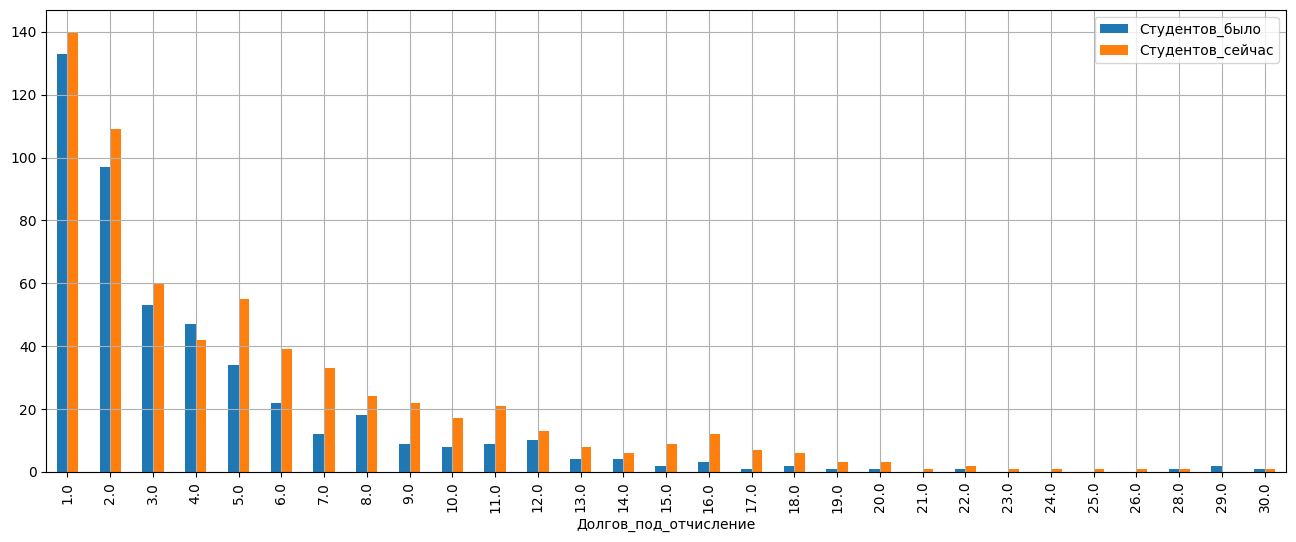

In [41]:
freq_1year = group_by_st_1year.groupby('Долги_больше_года')['Студент'].count()
freq_1year_table = pd.DataFrame(freq_1year).reset_index().rename(columns={'Долги_больше_года' : 'Долгов_под_отчисление', 'Студент' : 'Студентов_сейчас'})

if compare:
    prev_freq_1year = group_old1year_by_st_comp.groupby('Долги_было')['Студент'].count()
    prev_1year_table = pd.DataFrame(prev_freq_1year).reset_index().rename(columns={'Долги_было' : 'Долгов_под_отчисление', 'Студент' : 'Студентов_было'})
    comp_1year_table = prev_1year_table.merge(freq_1year_table, on='Долгов_под_отчисление', how='outer').fillna(0)


if compare:
    comp_1year_table.plot(kind='bar', x='Долгов_под_отчисление', y=['Студентов_было', 'Студентов_сейчас'], figsize=(16,6), grid=True)
else:
    freq_1year_table.plot(kind='bar', x='Долгов_под_отчисление', y='Студентов_сейчас', figsize=(16,6), grid=True)

In [42]:
data.query('Текущий_семестр - Семестр > 2')[['Преподаватель', 'Студент']].groupby(['Преподаватель']).count().sort_values('Студент', ascending=False).reset_index()

,Преподаватель,Студент
0,Милованова Евгения Алексеевна,130
1,Толстых Ольга Дмитриевна,110
2,Неизвестный,97
3,Петрякова Елена Алексеевна,69
4,Астраханцев Леонид Алексеевич,68
...,...,...
265,Мухопад Александр Юрьевич,1
266,Упырь Роман Юрьевич,1
267,Федоров Вячеслав Викторович,1
268,Федоров Марк Эдуардович,1


**Кого можно вытащить в ближайшее время? (от отчисления)**<br>
количество старых долгов <= 3-х

In [43]:
not_bad_1year = group_by_st_1year[group_by_st_1year['Долги_больше_года'] <= 3]
not_bad_1year.sort_values('Долги')

,Студент,Группа,Долги_больше_года,Долги
601,Сергеев Даниил Леонидович,"Э.9-22-1(И,О)",1,1
607,Соболевский Никита Павлович,"ЭЖД.1-20-3(И,О)",1,1
600,Семьянинова Ирина Дмитриевна,"УК.1-21-1(И,О)",1,1
505,Харитонов Дмитрий Сергеевич,"СЖД.2-20-1(И,О)",1,1
627,Меньшиков Дмитрий Дмитриевич,"С.1-22-1(И,О)",1,1
...,...,...,...,...
381,Иванов Кирилл Андреевич,"СОД.3-22-1(И,О)",3,21
329,Савельев Роман Николаевич,"УК.1-22-1(И,О)",3,21
355,Пеньков Игорь Станиславович,"СЖД.1-22-1(И,О)",3,23
352,Тугарин Ярослав Александрович,"ЭЖД.1-20-1(И,О)",3,24


Список долгов:

In [44]:
not_bad_list_1year = not_bad_1year.merge(data, on=['Студент', 'Группа'], how='inner').\
    query('Текущий_семестр - Семестр > 2')[['Студент', 'Группа', 'Предмет', 'Тип предмета', 'Преподаватель']]
not_bad_list_1year

,Студент,Группа,Предмет,Тип предмета,Преподаватель
0,Савельев Роман Николаевич,"УК.1-22-1(И,О)",Физика,зачет,Емельянова Анастасия Сергеевна
1,Савельев Роман Николаевич,"УК.1-22-1(И,О)",Общая физическая подготовка,зачет,Власов Е.А.
13,Савельев Роман Николаевич,"УК.1-22-1(И,О)",Информатика,экзамен,Мозолевская Анна Николаевна
21,Домбровский Денис Владимирович,"СЖД.3-20-1(И,О)",Гидрологические расчеты мостовых переходов,зачет,Никитина Юлия Григорьевна
22,Домбровский Денис Владимирович,"СЖД.3-20-1(И,О)",Цифровые технологии в профессиональной деятель...,зачет,Асалханова Татьяна Николаевна
...,...,...,...,...,...
2580,Мотов Илья Николаевич,"СОД.3-22-1(И,О)",Начертательная геометрия и компьютерная графика,зачет,Матиенко Лариса Владимировна
2584,Найденов Александр Андреевич,"Т.1-22-4(И,О)",Общая физическая подготовка,зачет,Гладышев Александр Александрович
2590,Нестеров Вадим Сергеевич,"СЖД.2-22-1(И,О)",Начертательная геометрия и компьютерная графика,зачет,Кочергина Наталия Григорьевна
2594,Огородников Борис Андреевич,"ИС.1-21-2(И,О)",Технологии программирования,зачет,Вергасов Александр Сергеевич


Преподаватели по данным спискам:

In [45]:
not_bad_list_1year[['Преподаватель', 'Студент']].groupby(['Преподаватель']).count().sort_values('Студент', ascending=False).reset_index()

,Преподаватель,Студент
0,Толстых Ольга Дмитриевна,40
1,Петрякова Елена Алексеевна,18
2,Милованова Евгения Алексеевна,18
3,Таирова Елена Викторовна,17
4,Гагин Виктор Евгеньевич,14
...,...,...
128,Гефан Григорий Давыдович,1
129,Неклюдова Анастасия Васильевна,1
130,Захарова Екатерина Валерьевна,1
131,Воронцов Владислав Николаевич,1


## Анализ по преподавателям

**Количество долгов по преподавателям**

In [46]:
data[['Преподаватель', 'Студент']].groupby(['Преподаватель']).count().sort_values('Студент', ascending=False).reset_index()

,Преподаватель,Студент
0,Неизвестный,285
1,Милованова Евгения Алексеевна,270
2,Толстых Ольга Дмитриевна,246
3,Панасенко Александр Николаевич,167
4,Тюкавкин-Плотников Алексей Александрович,166
...,...,...
363,Демаков В.И.,1
364,Съемщиков Сергей Евгеньевич,1
365,Синельникова Виктория Николаевна,1
366,Казанцева И.И.,1


**Должники по преподавателям и дисциплинам:**

In [47]:
data[['Преподаватель', 'Предмет','Студент']].groupby(['Преподаватель', 'Предмет']).count().sort_values('Преподаватель', ascending=True).reset_index()

,Преподаватель,Предмет,Студент
0,Абасова Наталья Иннокентьевна,Информационные технологии,18
1,Абасова Наталья Иннокентьевна,Методы и средства проектирования информационны...,19
2,Абасова Наталья Иннокентьевна,Проектирование информационных систем,1
3,Абасова Наталья Иннокентьевна,Технологии поиска информации,1
4,Абасова Наталья Иннокентьевна,Управление данными,8
...,...,...,...
928,Яковлева Нина Валерьевна,"Деньги, кредит и банки",4
929,Яковлева Нина Валерьевна,Экономическая безопасность,19
930,Ясько Светлана Витальевна,Химия,11
931,Ясько Светлана Витальевна,Безопасность жизнедеятельности,7


**"Принципиальные" преподаватели**<br>
количество единственных долгов у студентов в разрезе по преподавателям

In [48]:
only_one_dolg = group_by_st[group_by_st['Долги'] == 1].merge(
    data[['Студент', 'Группа', 'Преподаватель', 'Предмет', 'Тип предмета', 'Семестр', 'Текущий_семестр']],
    on=['Студент', 'Группа'], how='left')
only_one_dolg

,Студент,Группа,Долги,Преподаватель,Предмет,Тип предмета,Семестр,Текущий_семестр
0,Журавлева Влада Алексеевна,"Т.1-23-1(И,О)",1,Сухинина Ксения Викторовна,Общая физическая подготовка,зачет,2,3
1,Меньшиков Дмитрий Дмитриевич,"С.1-22-1(И,О)",1,Третьяков Валерий Григорьевич,"История (История России, Всеобщая история)",экзамен,2,5
2,Майстренко Светлана Сергеевна,"ИС.1-23-1(И,О)",1,Заика Роман Александрович,Вероятностные основы функционирования цифровых...,экзамен,2,3
3,Баранова Александра Алексеевна,"Т.1-22-4(И,О)",1,Тюкавкин-Плотников Алексей Александрович,Гражданское право,курсовая работа,4,5
4,Старикова Дарья Васильевна,"ЭЖД.1-21-2(И,О)",1,Давыдова Надежда Викторовна,Технология и управление работой станций и узлов,курсовой проект,6,7
...,...,...,...,...,...,...,...,...
177,Сушко Анастасия Денисовна,"Э.8-22-1(И,О)",1,Гладышев Александр Александрович,Общая физическая подготовка,зачет,4,5
178,Колодин Сергей Дмитриевич,"ИС.1-23-2(И,О)",1,Таирова Елена Викторовна,Математика,экзамен,2,3
179,Цыденова Ангелина Алдаровна,"М.3-21-1(И,О)",1,Самсонов Евгений Анатольевич,Финансовый менеджмент,курсовая работа,5,7
180,Бубнов Сергей Евгеньевич,"СОД.1-22-1(И,О)",1,Базилевский Михаил Павлович,Математика,экзамен,3,5


In [49]:
only_one_dolg[['Преподаватель', 'Студент']].groupby(['Преподаватель']).count().sort_values('Студент', ascending=False).reset_index()

,Преподаватель,Студент
0,Тюкавкин-Плотников Алексей Александрович,15
1,Лыткина Елена Михайловна,10
2,Ермошенко Юлия Владимировна,8
3,Григоренко Сергей Александрович,7
4,Мурзин Семен Витальевич,5
...,...,...
74,Лыженкова Рита Станиславовна,1
75,Лыткина Екатерина Михайловна,1
76,Мазитова Анна Юрьевна,1
77,Маланина Юлия Николаевна,1


**Еще более "принципиальные" преподаватели**<br>
количество единственных долгов старше 1 года, в разрезе по преподавателям

In [50]:
only_one_dolg_1year = group_by_st_1year[group_by_st_1year['Долги'] == 1].merge(
    data[['Студент', 'Группа', 'Преподаватель', 'Предмет', 'Тип предмета', 'Семестр', 'Текущий_семестр']],
    on=['Студент', 'Группа'], how='left')
only_one_dolg_1year

,Студент,Группа,Долги_больше_года,Долги,Преподаватель,Предмет,Тип предмета,Семестр,Текущий_семестр
0,Харитонов Дмитрий Сергеевич,"СЖД.2-20-1(И,О)",1,1,Толстых Ольга Дмитриевна,Математика,экзамен,3,9
1,Дик Алёна Алексеевна,"ТБ.2-21-1(И,О)",1,1,Мозолевская Анна Николаевна,Информатика,экзамен,2,7
2,Дмитриева Анна Андреевна,"Э.8-22-1(И,О)",1,1,Неизвестный,Основы финансовых вычислений,зачет,2,5
3,Ергалов Дмитрий Валентинович,"ЭЖД.1-22-2(И,О)",1,1,Таирова Елена Викторовна,Математика,экзамен,2,5
4,Бибичев Артём Васильевич,"БИ.4-21-1(И,О)",1,1,Лыткина Екатерина Михайловна,Численные методы,зачет,4,7
5,Коношонкин Вадим Андреевич,"ПСЖ.6-21-1(И,О)",1,1,Астраханцев Леонид Алексеевич,Электротехника и электроника,экзамен,4,7
6,Прокопьева Анастасия Алексеевна,"Э.8-21-1(И,О)",1,1,Неклюдова Анастасия Васильевна,Философия,экзамен,4,7
7,Семьянинова Ирина Дмитриевна,"УК.1-21-1(И,О)",1,1,Ларченко Анастасия Геннадьевна,Материаловедение,зачет,3,7
8,Сергеев Даниил Леонидович,"Э.9-22-1(И,О)",1,1,Неизвестный,Информатика,экзамен,2,5
9,Соболевский Никита Павлович,"ЭЖД.1-20-3(И,О)",1,1,Давыдова Надежда Викторовна,Технология и управление работой станций и узлов,курсовой проект,6,9


In [51]:
only_one_dolg_1year[['Преподаватель', 'Студент']].groupby(['Преподаватель']).count().sort_values('Студент', ascending=False).reset_index()

,Преподаватель,Студент
0,Неизвестный,2
1,Астраханцев Леонид Алексеевич,1
2,Давыдова Надежда Викторовна,1
3,Ларченко Анастасия Геннадьевна,1
4,Лыткина Екатерина Михайловна,1
5,Мозолевская Анна Николаевна,1
6,Неклюдова Анастасия Васильевна,1
7,Таирова Елена Викторовна,1
8,Толстых Ольга Дмитриевна,1
9,Третьяков Валерий Григорьевич,1


Конец